# Exercises

## Exercise 1
---

You can find below the code that was used to generate the activity of place cells on a linear track.
Use the code and the decoding procedure you lerned about in the lesson to explore how different features of the data impact our ability to decode position.
In particular:

A - Try to use different fractions of our data samples. How does the median error change when the the number of available sample gets larger? You do not need to re-generate any data, just randomly sub-sample the data to different fractions.

B - How many place cells do we need to reliably decode position? Try to re-do the decoding using only 10 cell, then 20, and so on. How does the median error change? Does it reach an asymptote? (Also in this case, you do not need to re-generate the data, you can just select a random subset of cells each time)

C - Generate new data using the code below, changing the firing rate noise (changing the value of the variable `noise firing_rate`). How does this noise impact the decoding? 

In [1]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

import pickle
import ipywidgets as widgets
from ipywidgets import interact
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

### Generate activity of place cells on a linear track

In [34]:
%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets


track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution

In [35]:
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))

In [36]:
# GENERATE TRAJECTORY

n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])


for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps

In [37]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 0.1 # the baseline noise firing rate
spikes = []

for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

In [ ]:
import pickle
import os

os.makedirs('data') #make directory called data

file_name = 'linear_track_data.pickle' # change this name when you save new data

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)

### Decoding

In [7]:
#download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/TliAW2xObyy0keu')

In [39]:
#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [40]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

In [41]:
spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

In [42]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

100%|██████████| 5026/5026 [00:16<00:00, 309.92it/s]


## Question A

        As we can see below, the median error actually does not change that much, which means our decoder is actually quite robust. the median error is slightly larger when only 25% of data is available, for 50% it is smaller and for 75% and 100% of the data it is even smaller, however, these are only very minimal differences. Our decoder can predict the position of the animal quite accurately even with a smaller subset of the data, which is a very good sign. What was expected was that the median error would decrease with more data being available, as the decoder would become more accurate at predicting the animal's position

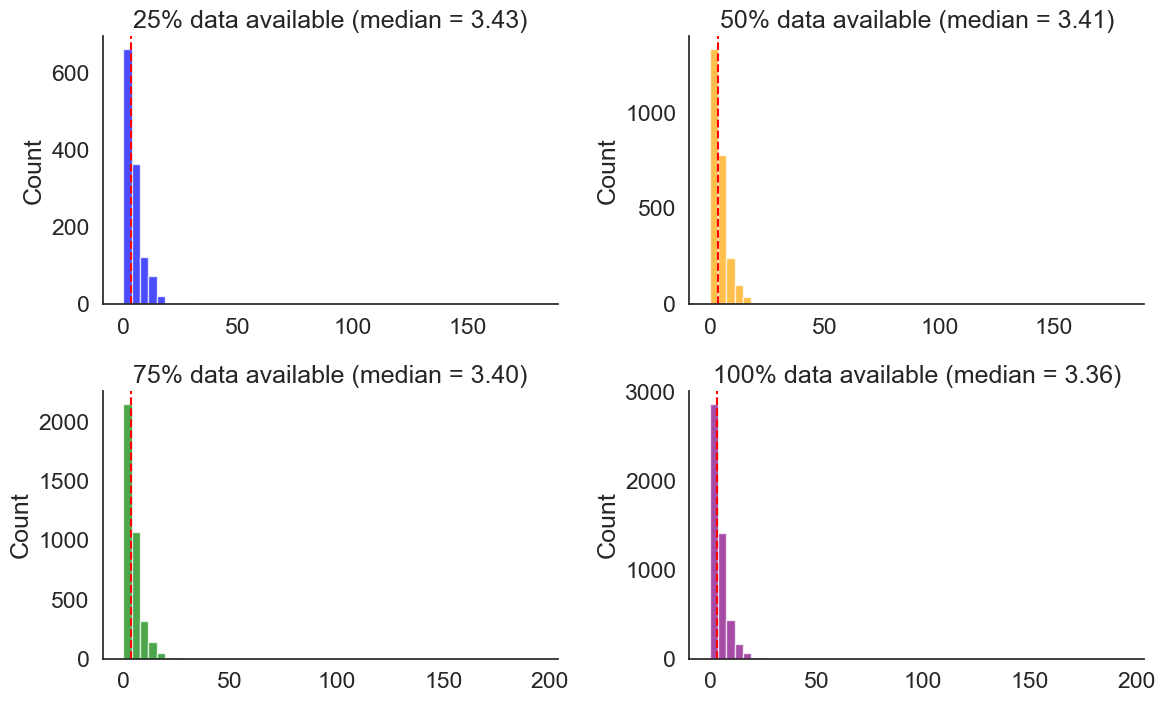

In [50]:
#create plot with subplots for the 4 different data availabilities
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

fractions = [0.25, 0.5, 0.75, 1.0] #25%, 50%, 75% and 100% of available data 
colors = ['blue', 'orange', 'green', 'purple']

for i, frac in enumerate(fractions):
    n_samples = int(len(true_x) * frac)
    valid_indices = np.where(~np.isnan(x_decoded))[0]
    selected_indices = np.random.choice(valid_indices, min(n_samples, len(valid_indices)), replace=False)

    true_subset = true_x[selected_indices]
    decoded_subset = x_decoded[selected_indices]
    errors = np.abs(true_subset - decoded_subset)
    median_error = np.median(errors)

    axs[i].hist(errors, bins=50, color=colors[i], alpha=0.7)
    axs[i].axvline(x=median_error, color='red', linestyle='--')
    axs[i].set_title(f"{int(frac*100)}% data available (median = {median_error:.2f})")
    axs[i].set_ylabel("Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Question B

        As we can see below, the median decoding error decreases with the number of place cells. After increasing the number of cells to 50, the error stabilizes a bit, and it almost fully stabilizes after 75 cells. This means that we do not need 100 place cells to accurately decode the position, using around 70-80 cells is enough.  

In [52]:
def decode_with_subset(spikes_count, firing_rate_maps, fps, space_bins, subset_cells):
    x_decoded = np.zeros(spikes_count.shape[0])

    for t_bin in range(spikes_count.shape[0]):
        # Select spike counts and firing rates only for subset_cells (cells are columns in spikes_count)
        spikes_subset = spikes_count[t_bin, subset_cells]
        fr_maps_subset = firing_rate_maps[subset_cells, :]

        if np.sum(spikes_subset) > 0:
            posterior = np.empty(fr_maps_subset.shape[1])
            for i in range(fr_maps_subset.shape[1]):
                posterior[i] = np.sum(poisson.logpmf(spikes_subset, fr_maps_subset[:, i] / fps) + 1e-15)
            x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        else:
            x_decoded[t_bin] = np.nan

    return x_decoded

In [55]:
n_cells = spikes_count.shape[1] 
subset_sizes = [10, 20, 30, 40, 50, 75, 100]  
median_errors = []

for size in subset_sizes:
    selected_cells = np.random.choice(n_cells, size=size, replace=False)

    x_decoded = decode_with_subset(spikes_count, firing_rate_maps, fps, space_bins, selected_cells)

    error = np.nanmedian(np.abs(x_decoded - true_x))
    median_errors.append(error)

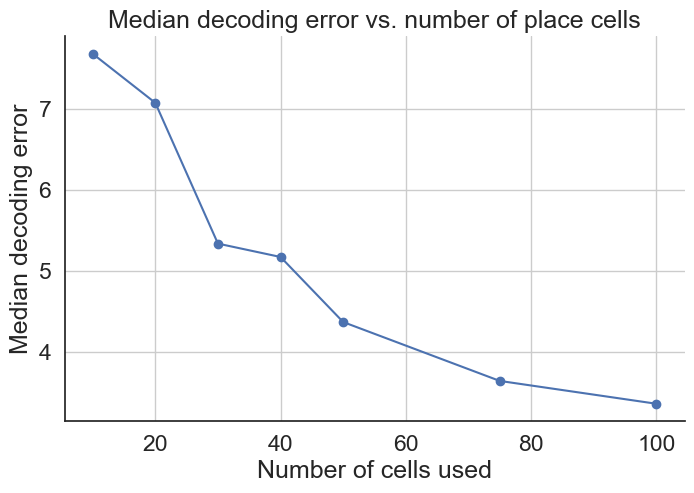

In [56]:
plt.figure(figsize=(8,5))
plt.plot(subset_sizes, median_errors, marker='o')
plt.xlabel('Number of cells used')
plt.ylabel('Median decoding error')
plt.title('Median decoding error vs. number of place cells')
plt.grid(True)
plt.show()

## Question C

        As we can see, when we increase the baseline firing rate noise, the accuracy of our decoder decreases. This is simply because our decoder cannot accurately predict noisy input, as it makes it harder to to distinguish true spatially tuned activity from random firing, reducing the ability of the decoder to attribute spikes to specific place fields.

In [ ]:
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))
noise_firing_rate = 1.0 #change baseline firing rate noise
spikes = []

for i in range(n_cells):
    inst_rate = true_firing_rate_maps[i,x_sampling.astype(np.int32)] + noise_firing_rate
    spikes_loc = np.random.poisson(inst_rate/sampling_rate)
    sp = np.argwhere(spikes_loc)
    t_sp = t_sampling[sp]
    spikes.append(t_sp)

In [39]:
file_name = 'linear_track_data_new.pickle' # change this name when you save new data

out_data = {}
out_data['x'] = x
out_data['t'] = t
out_data['spikes'] = spikes
out_data['track_length'] = track_length
out_data['fps'] = fps

with open('data/'+file_name,'wb') as f:
    pickle.dump(out_data,f)

In [40]:
#code: data import
data_file = 'data/linear_track_data_new.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [41]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

In [42]:
spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

In [43]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

100%|██████████| 5026/5026 [00:14<00:00, 351.50it/s]


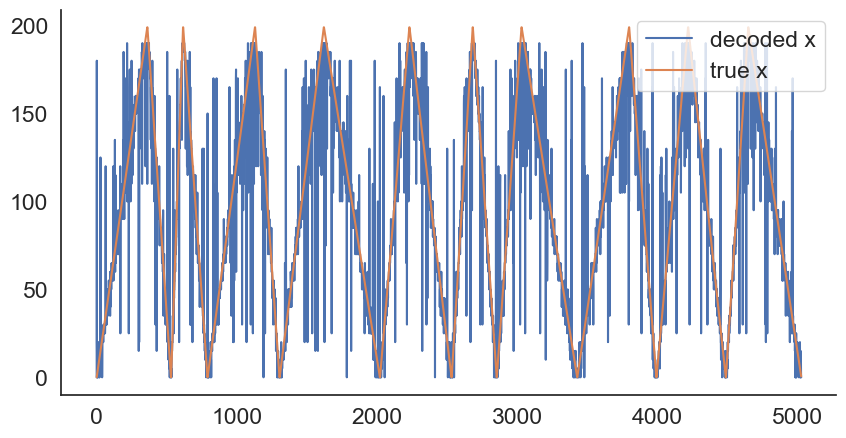

In [44]:
plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()

## Exercise 2
---
In the loop implementation of the decoder, we used `poisson.logpmf(k,mu)` to calculate the log probability of observing $k$ spikes given an average firing rate of $\mu$. 
This is mathematically equivalent to `np.log(poisson.pmf(k,mu))`, in which we calculate the probability, and then take the log.


Re-run the decoding substituting this expression:

```
posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
```

To the line we are using to calculate the posterior.
Do you see any difference in the results? What do you think this is due to?




        As we can see below when running the decoding while substituting the expression, our decoder becomes much worse at predicting the animal position, and the model seems to get less stable. in both of the expressions we add a small constant at the end to prevent the value log(0). However,with the substituted expression, we add the small constant before taking the logarithm, which changes the probability values before logging, leading to non-accurate likelihoods. This change disrupts the ability of the model to distinguish the animal's position based on the spike pattern, which we can see in the plot below and which we can also see by an increased mean error in the second plot. 

In [12]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            #posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   

100%|██████████| 5026/5026 [00:47<00:00, 106.06it/s]


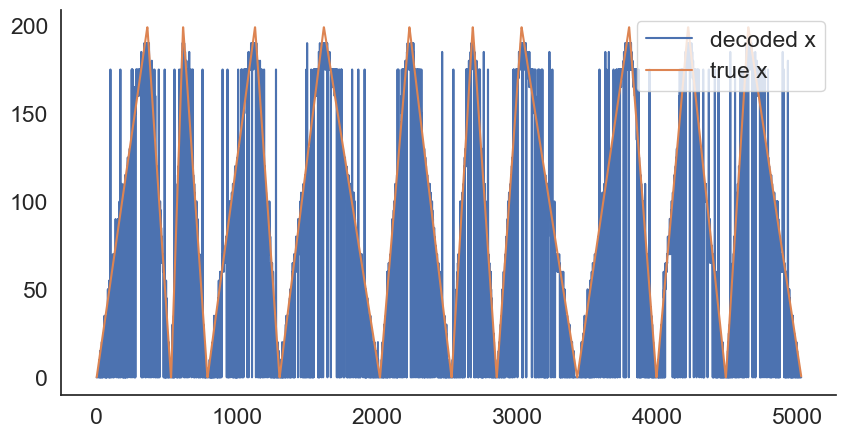

In [19]:
plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend(loc='upper right')

Median error: 6.407201828099659 cm


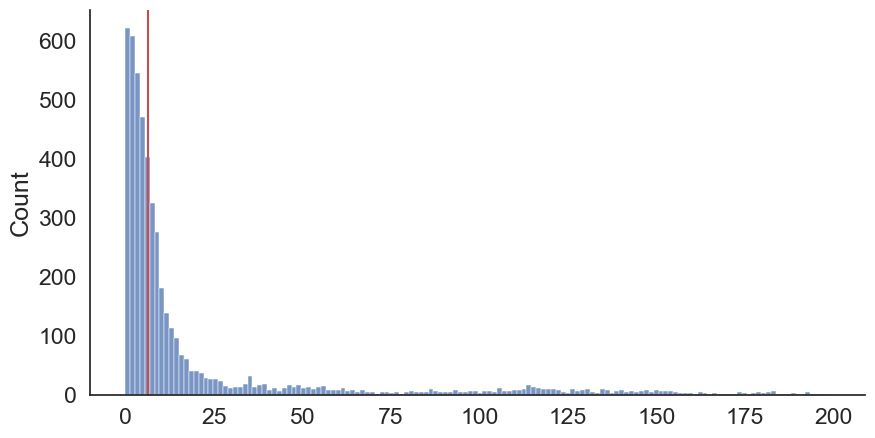

In [17]:
# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

## Exercise 3
---
A - Estimate the quality of the sequence detection methods we saw in the lesson. How many false poistive does it find? How many false negatives?

B - Investigate the effect of `noise_x_react` and `noise_t_react` on the false positive rate and the false negative rate of our detection procedure.

C - What kind of sequence can our methods detect? What kind of activity, despide being sequential, could escape our detection method? Would you have an idea for a different method for sequence detection?


In [ ]:
# generate data 

n_events = 200 # number of reactivation events
event_duration = 100 # in bins
sampling_rate = 100 # sampling rate 
t_react = np.arange(0,100)
noise_x_react=5; # Noise in the reactivation of the sequence
noise_t_react=5; # Noise in the timing of the spikes 
noise_firing_rate = 0.1 # the baseline noise firing rate


reactivation_events = np.zeros((n_events,event_duration))
spikes_react = np.zeros((n_events,n_cells,event_duration))

for event in range(n_events):
    if(event<=n_events//2):
    #Generate "real" sequences for the first half of events
        x_start = np.random.uniform(0,track_length) # Starting point
        x_end = np.random.uniform(0,track_length) # Ending point
        x_react = np.linspace(x_start,x_end,event_duration) \
            +np.random.normal(0,noise_x_react,size=event_duration)

    else:
        #Pick locations randomly for the second half 
        x_react = np.random.uniform(0,track_length,size=event_duration);

    x_react[x_react<0]=0;
    x_react[x_react>track_length]=track_length
    
    #store reactivation sequence
    reactivation_events[event,:] = x_react

    
    # Generate spikes according to the location being reactivated in this event
    
    for i in range(n_cells):
        binned_x = np.digitize(x_react,bins=np.linspace(0,track_length,firing_rate_maps.shape[-1]))-1
        inst_rate = firing_rate_maps[i,binned_x] + np.random.normal(0,noise_firing_rate,size=len(binned_x))
        inst_rate[inst_rate<0] = 0
        spikes_loc = np.where(np.random.poisson(inst_rate/sampling_rate)>0)
        spikes_loc = spikes_loc + np.round(np.random.normal(0,noise_t_react,size=len(spikes_loc)))
        spikes_loc = spikes_loc[np.logical_and(spikes_loc>0,spikes_loc<event_duration)]
        spikes_react[event,i,spikes_loc.astype(int)] = 1

In [61]:
time_window = 10 # number of bins to aggregate during decoding

reactivation_slope = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    # First we bin the events in windows of 10 bins
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//time_window))
    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//time_window):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*time_window :(t_r)*time_window],axis=1)

In [62]:
# to do: bayesian decoding
t_resize = 10 # We use spikes from multiple time windows for the decoding

reactivation_slopes = np.zeros(n_events)
reactivation_pvalues = np.zeros(n_events)

for event in range(n_events):

    event_spikes = spikes_react[event]
    spikes_sampled = np.zeros((n_cells,event_spikes.shape[1]//t_resize))

    # We generate a new spike matrix with the re-sized window
    for t_r in range(1,event_spikes.shape[1]//t_resize):
        spikes_sampled[:,t_r] = np.sum(event_spikes[:,(t_r-1)*t_resize :(t_r)*t_resize],axis=1)


    # We then perform decoding on the aggregated spikes
    x_decoded = np.zeros(spikes_sampled.shape[1])

    for t_bin in range(spikes_sampled.shape[1]):

        if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes

            posterior = np.empty(firing_rate_maps.shape[-1])
            for i in range(len(posterior)):
                posterior[i] = sum(poisson.logpmf(spikes_sampled[:,t_bin],firing_rate_maps[:,i]*t_resize/fps)+pow(1,-15))

            x_decoded[t_bin] = space_bins[np.argmax(posterior)]

        else:
            x_decoded[t_bin] = np.nan   

        # We fit a line to the decoded positions, and save the slope
        slope,_ = np.polyfit(np.arange(len(x_decoded)),x_decoded,deg=1)
        reactivation_slopes[event] = slope
        # And calculate the pvalue of the pearson correlation
        corr = pearsonr(np.arange(len(x_decoded)),x_decoded)
        reactivation_pvalues[event] = corr[1]

C:\Users\Beheerder\AppData\Local\Temp\ipykernel_21496\59900195.py:37: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = pearsonr(np.arange(len(x_decoded)),x_decoded)


<Axes: ylabel='Count'>

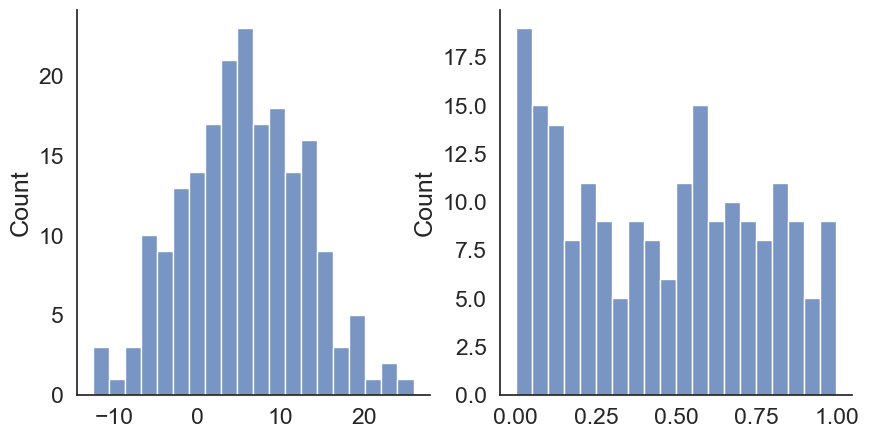

In [63]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.histplot(reactivation_slopes,bins=20)
plt.subplot(1,2,2)
sns.histplot(reactivation_pvalues,bins=20)

### Question A

        The decoder detected 11 out of 100 true sequences (11% sensitivity), which is quite low. It only produced 11 false positives among the 100 random events. This shows that our current method is rather specific, but not as sensitive. So the quality of the sequence detection method we used in the lesson is not that great.

In [ ]:
#detected sequence when pvalue is smaller than 0.05
detected_sequences = reactivation_pvalues < 0.05

true_positives = np.sum(detected_sequences[:n_events // 2])
false_negatives = (n_events // 2) - true_positives

false_positives = np.sum(detected_sequences[n_events // 2:])
true_negatives = (n_events // 2) - false_positives

print("True Positives:", true_positives)
print("False Negatives:", false_negatives)
print("False Positives:", false_positives)
print("True Negatives:", true_negatives)

True Positives: 11
False Negatives: 89
False Positives: 11
True Negatives: 89


### Question B

As the values for `noise_x_react` and `noise_t_react` are increased, the number of false positives increases while true positives decrease slightly, while true positives don't change that much. This suggestt hat adding spatial or temporal noise to the reactivation events makes the detection method less precise, leading to more ranodm patterns being detected as sequences. Therefore, both types of noise negatively affect the reliability of the detection method.

In [71]:
#decrease the number of events for quicker testing
n_events_small = 60  # 30 real + 30 random

#function
def simulate_detection_fast(noise_x_react, noise_t_react):
    reactivation_pvalues = np.zeros(n_events_small)
    
    for event in range(n_events_small):
        if event <= n_events_small // 2:
            x_start = np.random.uniform(0, track_length)
            x_end = np.random.uniform(0, track_length)
            x_react = np.linspace(x_start, x_end, event_duration) + np.random.normal(0, noise_x_react, size=event_duration)
        else:
            x_react = np.random.uniform(0, track_length, size=event_duration)

        x_react = np.clip(x_react, 0, track_length)
        spikes_event = np.zeros((n_cells, event_duration))

        for i in range(n_cells):
            binned_x = np.digitize(x_react, bins=np.linspace(0, track_length, firing_rate_maps.shape[-1])) - 1
            inst_rate = firing_rate_maps[i, binned_x] + np.random.normal(0, noise_firing_rate, size=len(binned_x))
            inst_rate[inst_rate < 0] = 0
            spikes_loc = np.where(np.random.poisson(inst_rate / sampling_rate) > 0)
            spikes_loc = spikes_loc[0] + np.round(np.random.normal(0, noise_t_react, size=len(spikes_loc[0])))
            spikes_loc = spikes_loc[np.logical_and(spikes_loc > 0, spikes_loc < event_duration)]
            spikes_event[i, spikes_loc.astype(int)] = 1

        t_resize = 10
        spikes_sampled = np.zeros((n_cells, event_duration // t_resize))
        for t_r in range(1, event_duration // t_resize):
            spikes_sampled[:, t_r] = np.sum(spikes_event[:, (t_r - 1) * t_resize: t_r * t_resize], axis=1)

        x_decoded = np.zeros(spikes_sampled.shape[1])
        for t_bin in range(spikes_sampled.shape[1]):
            if np.sum(spikes_sampled[:, t_bin]) > 0:
                posterior = np.empty(firing_rate_maps.shape[-1])
                for i in range(len(posterior)):
                    posterior[i] = np.sum(poisson.logpmf(spikes_sampled[:, t_bin], firing_rate_maps[:, i] * t_resize / fps) + 1e-15)
                x_decoded[t_bin] = space_bins[np.argmax(posterior)]
            else:
                x_decoded[t_bin] = np.nan

        valid = ~np.isnan(x_decoded)
        if np.sum(valid) > 1:
            corr = pearsonr(np.arange(len(x_decoded))[valid], x_decoded[valid])
            reactivation_pvalues[event] = corr[1]
        else:
            reactivation_pvalues[event] = 1.0

    detected_sequences = reactivation_pvalues < 0.05
    true_positives = np.sum(detected_sequences[:n_events_small // 2])
    false_negatives = (n_events_small // 2) - true_positives
    false_positives = np.sum(detected_sequences[n_events_small // 2:])
    true_negatives = (n_events_small // 2) - false_positives

    return true_positives, false_negatives, false_positives, true_negatives

#smaller noise grid
x_noise_vals_small = [0, 5, 10]
t_noise_vals_small = [0, 5, 10]

#run the simulation
results_small = {}
for x_noise in x_noise_vals_small:
    for t_noise in t_noise_vals_small:
        results_small[(x_noise, t_noise)] = simulate_detection_fast(x_noise, t_noise)

cleaned_results = {k: tuple(int(x) for x in v) for k, v in results_small.items()}

cleaned_results


{(0, 0): (5, 25, 2, 28),
 (0, 5): (1, 29, 3, 27),
 (0, 10): (4, 26, 1, 29),
 (5, 0): (5, 25, 4, 26),
 (5, 5): (5, 25, 3, 27),
 (5, 10): (5, 25, 5, 25),
 (10, 0): (3, 27, 2, 28),
 (10, 5): (4, 26, 0, 30),
 (10, 10): (6, 24, 2, 28)}

### Question C

        Our current method is best at predicting sequential events, but it struggles more with the random (non-sequence) events. This makes it that our model is less applicable in real-life scenarios, where animal movement is often non-linear and more variable. An alternative to our model is to use hidden markov models (HMMs). Unlike our linear decoder, HMMs treat the position of the animal as a hidden state that evolves over time, and it models neural spikes as observations generated by these states, By capturing these temporal transitions between states, HMMs can accurately decode sequences even when the spike data is more random or noisy.